# Model Comparison — YOLOv5nu vs YOLOv8n vs YOLOv8s

This notebook compares the three extended-training YOLO variants and uses the comparison to justify the final demonstration model.

It covers:
1. Overall metrics and weighted score
2. Training convergence curves
3. Precision-Recall curves
4. F1 curves
5. Confusion matrices
6. Inference speed
7. Sample predictions for the selected model

**Prerequisite:** `02_training.ipynb` should be completed first.


In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "ultralytics", "matplotlib", "pandas", "-q"], check=True)
print("Dependencies ready ✓")

Dependencies ready ✓


In [2]:
import json, os, time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUNS = ROOT / "runs" / "train"
FIGS = ROOT / "figures"
FIGS.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("YOLO_CONFIG_DIR", str(ROOT / ".ultralytics"))

MODELS = [
    {"name": "yolov5nu_300ep", "label": "YOLOv5nu"},
    {"name": "yolov8n_300ep",  "label": "YOLOv8n"},
    {"name": "yolov8s_300ep",  "label": "YOLOv8s"},
]
COLORS = ["#e53935", "#1e88e5", "#43a047"]

device = "0" if torch.cuda.is_available() else "cpu"

def find_run_dir(model_name):
    for base in [RUNS, ROOT / "a3_300ep_bundle" / "train"]:
        p = base / model_name
        if p.exists():
            return p
    return None

print("Root:   ", ROOT)
print("Device: ", device)
if torch.cuda.is_available():
    print("GPU:    ", torch.cuda.get_device_name(0))

Root:    /mnt/custom-file-systems/efs/fs-02d21030926db1df2_fsap-0de09adebc257215c
Device:  0
GPU:     Tesla T4


## 1. Metrics Summary & Weighted Score

In [3]:
WEIGHTS = {"mAP@0.5:0.95": 0.50, "mAP@0.5": 0.25, "Recall": 0.15, "Precision": 0.10}

rows = []
for cfg in MODELS:
    run_dir = find_run_dir(cfg["name"])
    if run_dir is None:
        print(f"Missing run dir for {cfg['name']}")
        continue
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        print(f"Missing results.csv: {csv_path}")
        continue
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    best = df.loc[df["metrics/mAP50-95(B)"].idxmax()]
    p  = round(float(best["metrics/precision(B)"]), 5)
    r  = round(float(best["metrics/recall(B)"]),    5)
    m5 = round(float(best["metrics/mAP50(B)"]),     5)
    m9 = round(float(best["metrics/mAP50-95(B)"]),  5)
    ws = round(m9*0.50 + m5*0.25 + r*0.15 + p*0.10, 6)
    rows.append({"Model": cfg["label"], "Precision": p, "Recall": r, "mAP@0.5": m5, "mAP@0.5:0.95": m9, "Weighted score": ws})

summary = pd.DataFrame(rows).sort_values("Weighted score", ascending=False).reset_index(drop=True)
display(summary)


,Model,Precision,Recall,mAP@0.5,mAP@0.5:0.95,Weighted score
0,YOLOv8n,0.99183,0.99476,0.99389,0.87068,0.932210
1,YOLOv5nu,0.99431,0.99581,0.99385,0.86981,0.932170
2,YOLOv8s,0.99387,0.99667,0.99382,0.86946,0.932072


## 2. Metrics Bar Chart

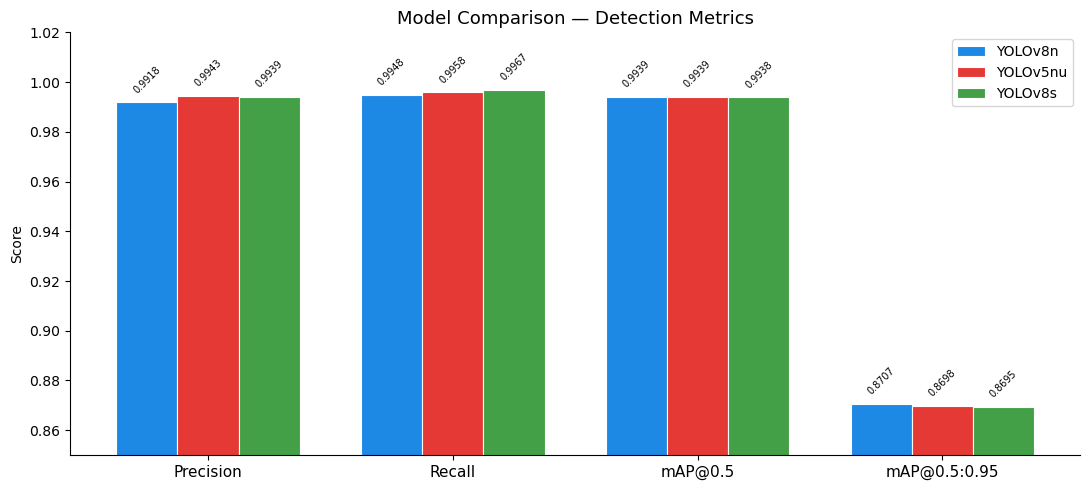

In [4]:
metrics_to_plot = ["Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"]
x = range(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, row in summary.iterrows():
    vals = [row[m] for m in metrics_to_plot]
    offset = (i - 1) * width
    color = COLORS[next(j for j,m in enumerate(MODELS) if m["label"]==row["Model"])]
    bars = ax.bar([xi + offset for xi in x], vals, width, label=row["Model"],
                  color=color, edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{v:.4f}", ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(list(x))
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Detection Metrics", fontsize=13)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS / "fig_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Training Convergence — mAP Over Epochs

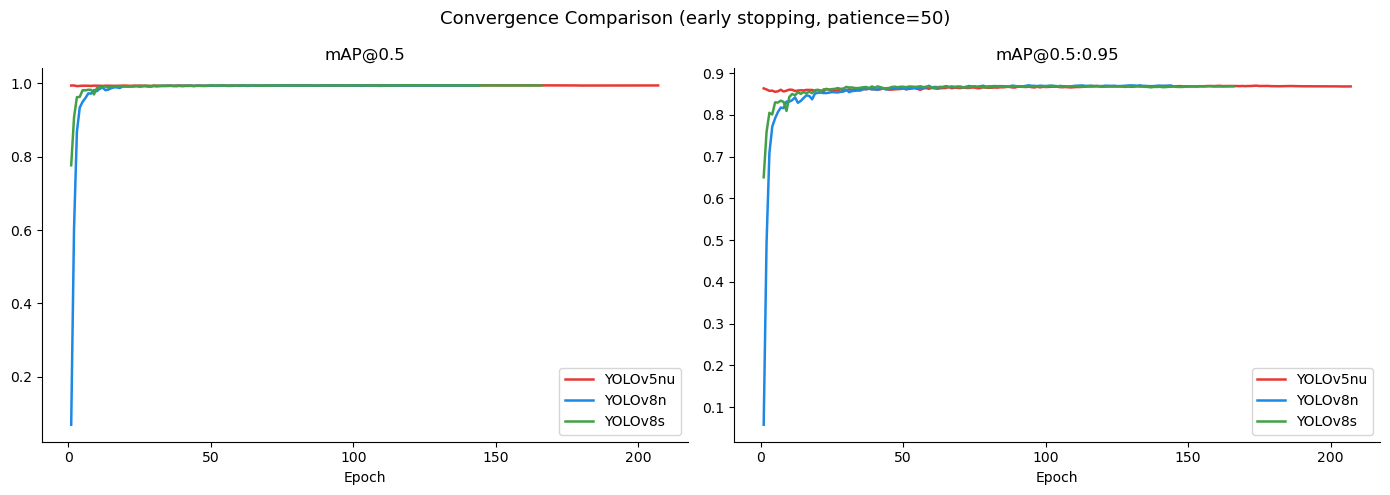

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cfg, color in zip(MODELS, COLORS):
    run_dir = find_run_dir(cfg["name"])
    if run_dir is None: continue
    df = pd.read_csv(run_dir / "results.csv")
    df.columns = df.columns.str.strip()
    axes[0].plot(df["epoch"], df["metrics/mAP50(B)"],
                 label=cfg["label"], color=color, linewidth=1.8)
    axes[1].plot(df["epoch"], df["metrics/mAP50-95(B)"],
                 label=cfg["label"], color=color, linewidth=1.8)

for ax, title in zip(axes, ["mAP@0.5", "mAP@0.5:0.95"]):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Convergence Comparison (early stopping, patience=50)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / "fig_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Precision-Recall Curves

Generated by Ultralytics at the end of training.  
A near-perfect curve hugging the top-right corner confirms the models detect all 200 SKUs with high confidence.

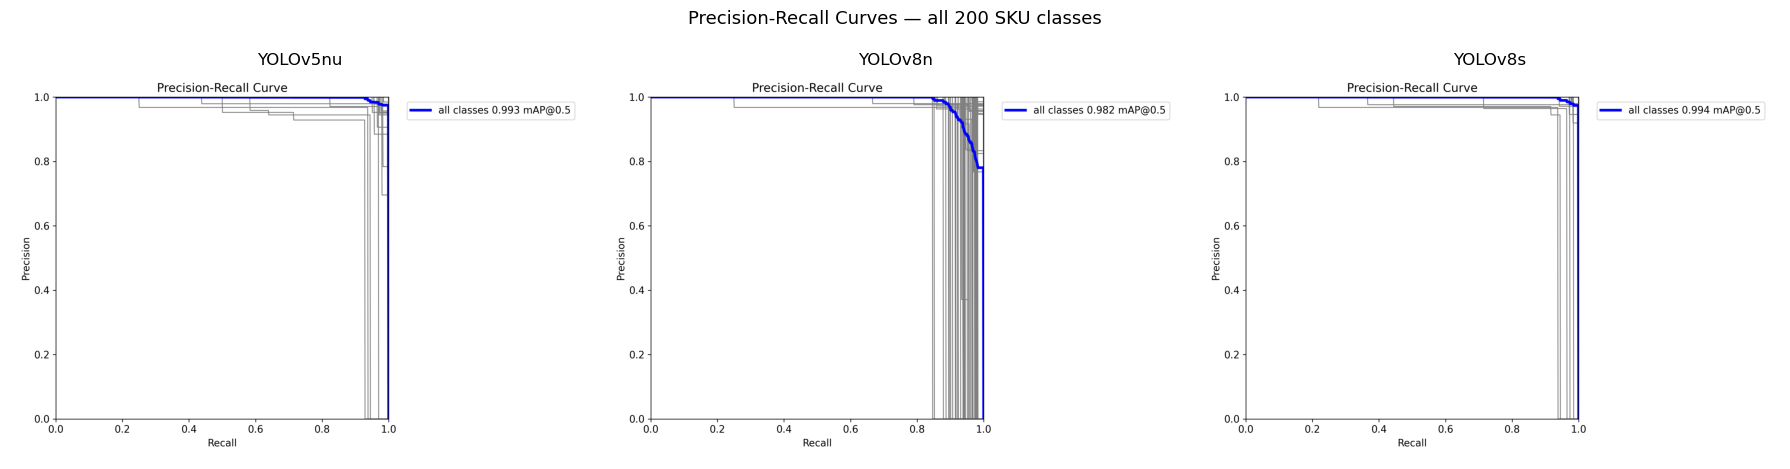

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cfg in zip(axes, MODELS):
    run_dir = find_run_dir(cfg["name"])
    img_path = run_dir / "BoxPR_curve.png" if run_dir else None
    if img_path and img_path.exists():
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(cfg["label"], fontsize=12)
    else:
        ax.set_title(f"{cfg['label']} — not found")
    ax.axis("off")
plt.suptitle("Precision-Recall Curves — all 200 SKU classes", fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / "fig_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. F1 Curves

F1 score vs confidence threshold. The peak F1 indicates the optimal confidence cut-off for deployment.

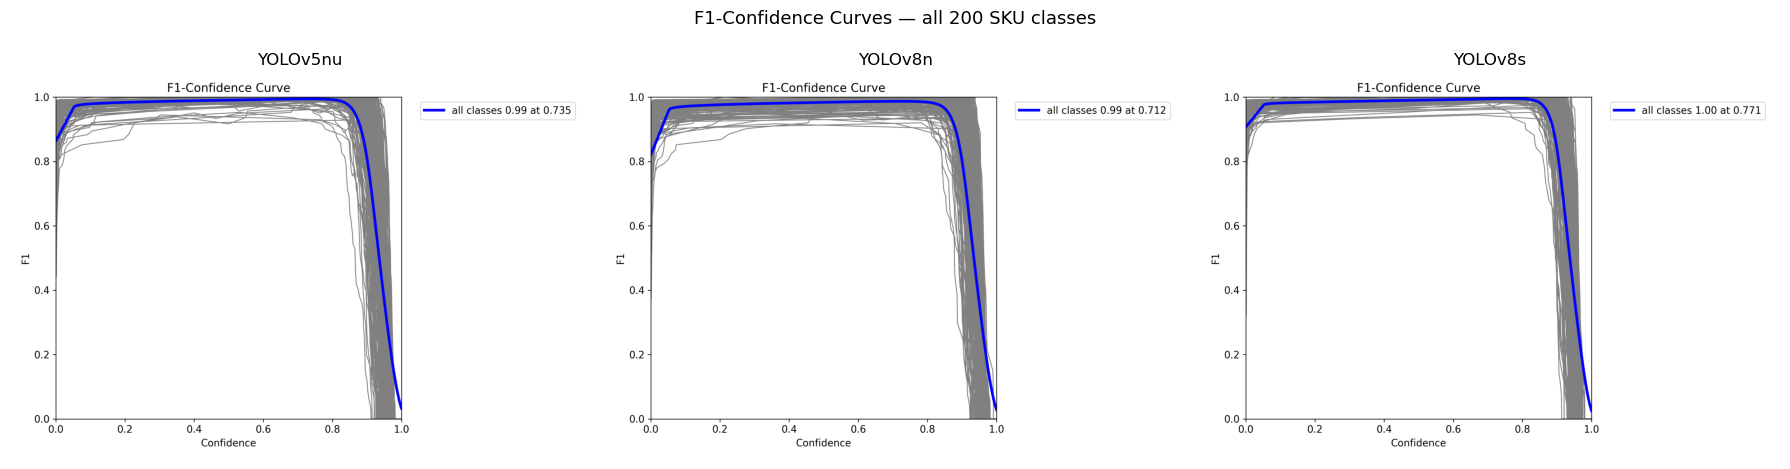

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cfg in zip(axes, MODELS):
    run_dir = find_run_dir(cfg["name"])
    img_path = run_dir / "BoxF1_curve.png" if run_dir else None
    if img_path and img_path.exists():
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(cfg["label"], fontsize=12)
    else:
        ax.set_title(f"{cfg['label']} — not found")
    ax.axis("off")
plt.suptitle("F1-Confidence Curves — all 200 SKU classes", fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / "fig_f1_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Confusion Matrices

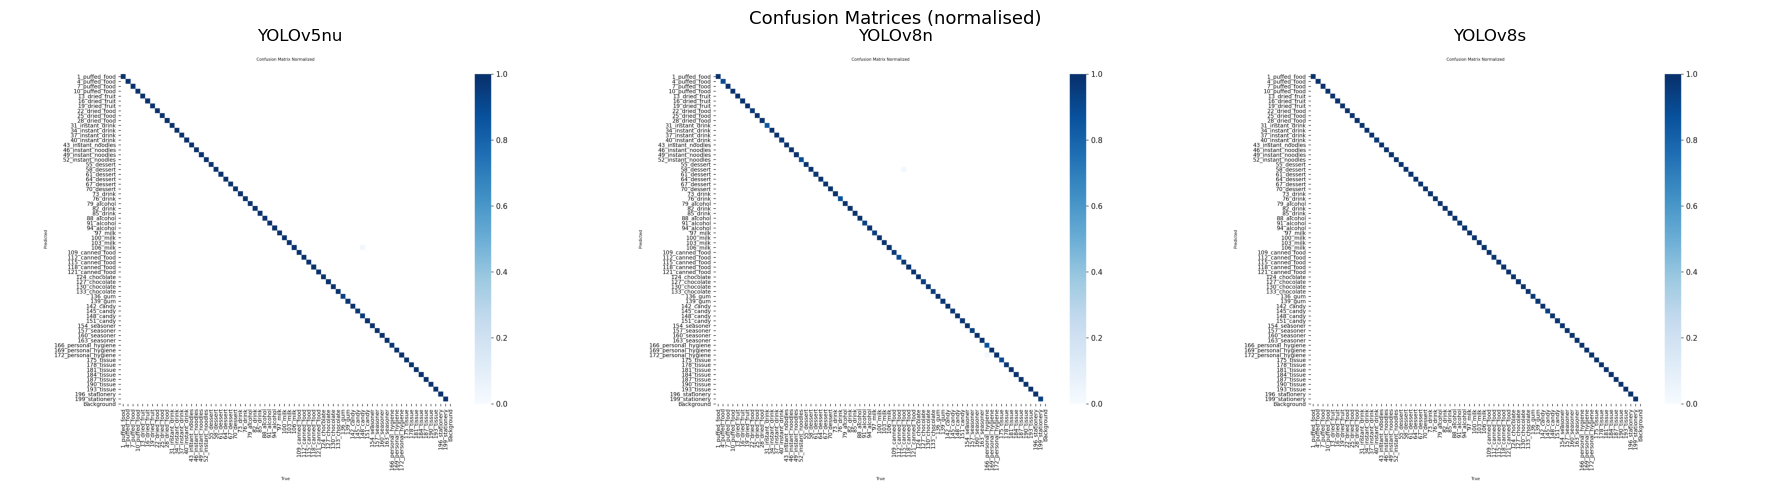

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cfg in zip(axes, MODELS):
    run_dir = find_run_dir(cfg["name"])
    if run_dir:
        cm_path = run_dir / "confusion_matrix_normalized.png"
        if not cm_path.exists():
            cm_path = run_dir / "confusion_matrix.png"
    else:
        cm_path = None
    if cm_path and cm_path.exists():
        ax.imshow(mpimg.imread(cm_path))
        ax.set_title(cfg["label"], fontsize=12)
    else:
        ax.set_title(f"{cfg['label']} — not found")
    ax.axis("off")
plt.suptitle("Confusion Matrices (normalised)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / "fig_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Inference Speed Comparison

WARNING ⚠️ torchvision==0.24 is incompatible with torch==2.8.
Run 'pip install torchvision==0.23' to fix torchvision or 'pip install -U torch torchvision' to update both.
For a full compatibility table see https://github.com/pytorch/vision#installation


   Model  Mean (ms)  Std (ms)  FPS
YOLOv5nu       24.9       7.8 40.2
 YOLOv8n       21.1       2.0 47.3
 YOLOv8s       23.5       0.2 42.6


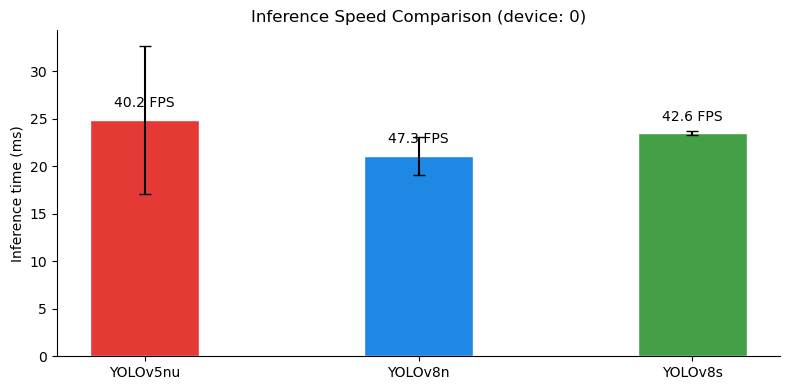

In [9]:
import numpy as np
from ultralytics import YOLO as _YOLO

test_imgs = list((ROOT / "data" / "processed" / "smart_checkout_yolo" / "test" / "images").glob("*.jpg"))
if not test_imgs:
    test_imgs = list((ROOT / "demo" / "images").glob("*.jpg"))

if not test_imgs:
    print("No test images found for speed benchmark — skipped.")
else:
    bench_img = str(test_imgs[0])
    speed_rows = []
    for cfg in MODELS:
        run_dir = find_run_dir(cfg["name"])
        if run_dir is None: continue
        best_pt = run_dir / "weights" / "best.pt"
        if not best_pt.exists(): continue
        model = _YOLO(str(best_pt))
        for _ in range(3):
            model.predict(bench_img, conf=0.25, verbose=False)
        times = []
        for _ in range(20):
            t0 = time.perf_counter()
            model.predict(bench_img, conf=0.25, verbose=False)
            times.append((time.perf_counter() - t0) * 1000)
        speed_rows.append({"Model": cfg["label"],
                            "Mean (ms)": round(np.mean(times), 1),
                            "Std (ms)":  round(np.std(times), 1),
                            "FPS":       round(1000 / np.mean(times), 1)})
    speed_df = pd.DataFrame(speed_rows)
    print(speed_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(speed_df["Model"], speed_df["Mean (ms)"],
                  color=COLORS[:len(speed_df)], edgecolor="white", width=0.4)
    ax.errorbar(speed_df["Model"], speed_df["Mean (ms)"],
                yerr=speed_df["Std (ms)"], fmt="none", color="black", capsize=4)
    for bar, fps in zip(bars, speed_df["FPS"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{fps} FPS", ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Inference time (ms)")
    ax.set_title(f"Inference Speed Comparison (device: {device})")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIGS / "fig_speed.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. Sample Predictions — YOLOv8n


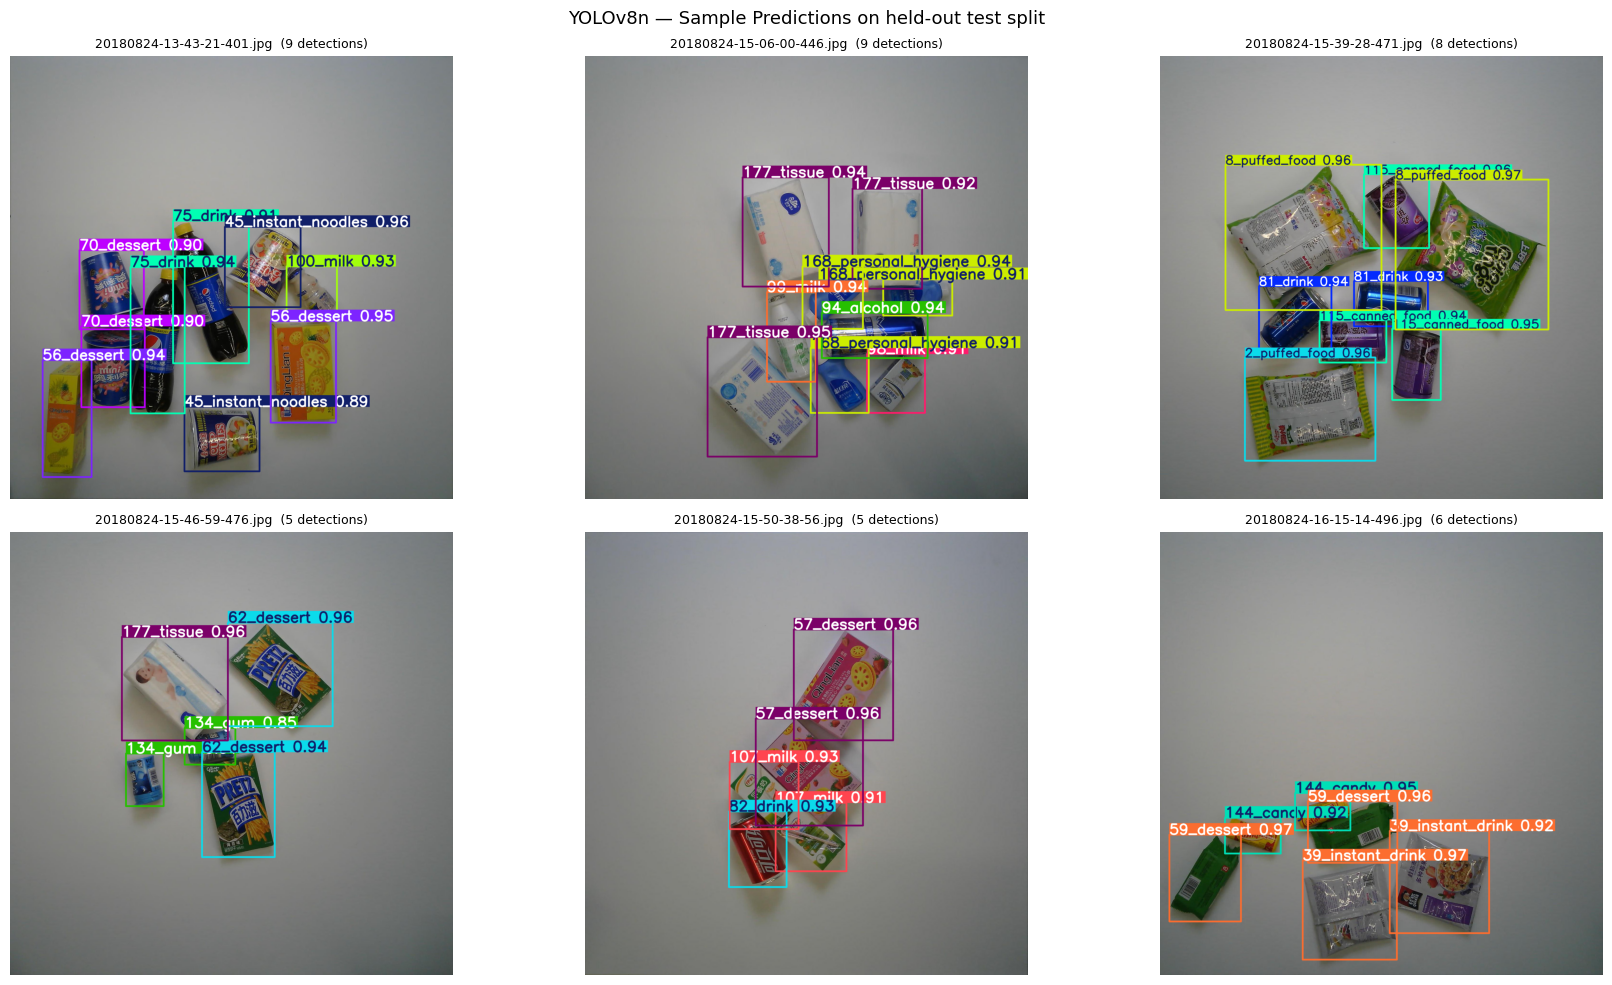

In [10]:
run_dir = find_run_dir("yolov8n_300ep")
best_pt = run_dir / "weights" / "best.pt" if run_dir else None

test_dir = ROOT / "data" / "processed" / "smart_checkout_yolo" / "test" / "images"
sample_imgs = sorted(test_dir.glob("*.jpg"))[:6]

if not sample_imgs:
    print("No test images found")
elif not best_pt or not best_pt.exists():
    print("YOLOv8n weights not found:", best_pt)
else:
    model = _YOLO(str(best_pt))
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for ax, img_path in zip(axes.flat, sample_imgs):
        result = model.predict(str(img_path), conf=0.25, verbose=False)[0]
        annotated = result.plot()
        ax.imshow(annotated[..., ::-1])
        n = len(result.boxes) if result.boxes is not None else 0
        ax.set_title(f"{img_path.name[:25]}  ({n} detections)", fontsize=9)
        ax.axis("off")
    plt.suptitle("YOLOv8n — Sample Predictions on held-out test split", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGS / "fig_sample_predictions.png", dpi=120, bbox_inches="tight")
    plt.show()

## 9. Final Summary

The three extended-training models are extremely close numerically. The final selection therefore follows the predefined weighted evaluation scheme rather than visual guesswork alone.


In [11]:
print("=" * 65)
print("MODEL COMPARISON SUMMARY")
print("=" * 65)
print(summary[["Model","mAP@0.5","mAP@0.5:0.95","Recall","Precision","Weighted score"]].to_string(index=False))
print()
spread = summary["Weighted score"].max() - summary["Weighted score"].min()
print("All models achieve extremely similar final performance after extended training.")
print("Weighted score spread: {:.6f} — effectively a very narrow margin.".format(spread))
print()
best = summary.iloc[0]
print(f"Selected for final demonstration: {best['Model']}")
print("  Reason: highest weighted score under the predefined evaluation scheme;")
print("  strongest mAP@0.5:0.95 among the three models;")
print("  overall margin is small, but the ranking remains internally consistent.")
print()
figs_saved = sorted(FIGS.glob("fig_*.png"))
print(f"Figures saved ({len(figs_saved)}):")
for f in figs_saved:
    print(f"  {f.name}")


MODEL COMPARISON SUMMARY
   Model  mAP@0.5  mAP@0.5:0.95  Recall  Precision  Weighted score
 YOLOv8n  0.99389       0.87068 0.99476    0.99183        0.932210
YOLOv5nu  0.99385       0.86981 0.99581    0.99431        0.932170
 YOLOv8s  0.99382       0.86946 0.99667    0.99387        0.932072

All models achieve extremely similar final performance after extended training.
Weighted score spread: 0.000138 — effectively a very narrow margin.

Selected for final demonstration: YOLOv8n
  Reason: highest weighted score under the predefined evaluation scheme;
  strongest mAP@0.5:0.95 among the three models;
  overall margin is small, but the ranking remains internally consistent.

Figures saved (12):
  fig_ann_distribution.png
  fig_confusion_matrices.png
  fig_convergence.png
  fig_f1_curves.png
  fig_level_distribution.png
  fig_metrics_bar.png
  fig_pr_curves.png
  fig_sample_predictions.png
  fig_sample_scenes.png
  fig_speed.png
  fig_top30_sku.png
  fig_training_curves.png
